# Phase 1: Data Engineering & Preparation
## Agricultural Risk Dashboard

In this notebook we load all 12 raw datasets, calculate daily log returns, synchronize them by date, and produce a clean master CSV for the next phases.

### 1.1 Load All Datasets

In [1]:
import pandas as pd
import numpy as np
import os

RAW_PATH = 'data/raw/'

files = {
    'Corn': 'corn_raw.csv',
    'Soybean': 'soybean_raw.csv',
    'Wheat': 'wheat_raw.csv',
    'Cotton': 'cotton_raw.csv',
    'Coffee': 'coffee_raw.csv',
    'Oats': 'oats_raw.csv',
    'Sugar': 'sugar_raw.csv',
    'Soybean_Oil': 'soybean_oil_raw.csv',
    'Lumber': 'lumber_raw.csv',
    'SP500': 'sp-500_raw.csv',
    'Crude_Oil': 'crude_oil_raw.csv',
    'USD_Index': 'us_dollar_index_raw.csv'
}

datasets = {}
for name, filename in files.items():
    df = pd.read_csv(os.path.join(RAW_PATH, filename))
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.rename(columns={'Value': name})
    datasets[name] = df
    print(f'{name:<15} {len(df):>6} rows  |  {df["Date"].iloc[0].date()} to {df["Date"].iloc[-1].date()}')

Corn             10180 rows  |  1986-01-02 to 2026-03-06
Soybean          10177 rows  |  1986-01-02 to 2026-03-06
Wheat            10179 rows  |  1986-01-02 to 2026-03-06
Cotton           10186 rows  |  1986-01-02 to 2026-03-06
Coffee           10182 rows  |  1986-01-02 to 2026-03-06
Oats             10144 rows  |  1986-01-02 to 2026-03-06
Sugar            10186 rows  |  1986-01-02 to 2026-03-06
Soybean_Oil      10138 rows  |  1986-01-02 to 2026-03-06
Lumber           10139 rows  |  1986-01-02 to 2026-03-06
SP500            10122 rows  |  1986-01-02 to 2026-03-06
Crude_Oil        10478 rows  |  1986-01-02 to 2026-03-02
USD_Index        10262 rows  |  1986-01-02 to 2026-03-06


### 1.1b Data Quality Fix Lumber Contract Transition (May–Jun 2023) // added later in the project

The lumber futures contract restructured in May 2023. The old contract stopped trading mid-May. The new Lumber contract started quoting mid-June. Between those dates no contract was actively quoted, and the data vendor carried the last settled value (344.00) forward every day. When the new contract finally settled on 2023-06-20 it printed at 536.5, creating a single-day log return of about +44%.

Mark Lumber's prices over this window as missing. The inner join downstream will then drop those dates into Phase 2 residuals and Phase 3 regime detection.


In [ ]:
lumber_df = datasets['Lumber']
mask = (lumber_df['Date'] >= '2023-05-16') & (lumber_df['Date'] <= '2023-06-19')
n_dropped = int(mask.sum())
lumber_df.loc[mask, 'Lumber'] = np.nan
datasets['Lumber'] = lumber_df


Lumber: set 25 rows to NaN (2023-05-16 to 2023-06-19, contract transition)


### 1.2 Calculate Log Returns

Calculate the daily natural log return for every asset to normalize the data distribution:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

In [1]:
for name, df in datasets.items():
    df[name] = df[name].where(df[name] > 0)
    df['Log_Return'] = np.log(df[name] / df[name].shift(1))
    datasets[name] = df

# sample log returns for Corn
datasets['Corn'][['Date', 'Corn', 'Log_Return']].head(10)

NameError: name 'datasets' is not defined

### 1.3 Merge & Synchronize

Merge all 12 datasets on Date using an inner join. This keeps only dates where all assets have data

In [ ]:
# Merge all datasets on Date
master = datasets['Corn'][['Date', 'Log_Return']].rename(columns={'Log_Return': 'Corn'})

for name in list(files.keys())[1:]:
    df = datasets[name][['Date', 'Log_Return']].rename(columns={'Log_Return': name})
    master = pd.merge(master, df, on='Date', how='inner')

# Drop the first row (NaN from log return calculation) and any remaining nulls
master = master.dropna()

print(f'Master dataset: {master.shape[0]} rows x {master.shape[1]} columns')
print(f'Date range: {master["Date"].iloc[0].date()} to {master["Date"].iloc[-1].date()}')
print(f'Missing values: {master.isnull().sum().sum()}')
master.head(10)

Master dataset: 9601 rows x 13 columns
Date range: 1986-01-03 to 2026-03-02
Missing values: 0



,Date,Corn,Soybean,Wheat,Cotton,Coffee,Oats,Sugar,Soybean_Oil,Lumber,SP500,Crude_Oil,USD_Index
1,1986-01-03,-0.002112,-0.011461,-0.026013,0.000000,0.048790,0.000000,0.006309,-0.007750,0.002005,0.006136,0.017068,0.014074
2,1986-01-06,0.004219,0.007656,0.005839,0.000000,0.046520,0.003527,0.004184,-0.027844,-0.010738,-0.001091,0.020180,-0.006285
3,1986-01-07,0.002103,0.012317,0.005806,0.000000,0.127833,0.003515,0.050876,0.007501,0.017392,0.014843,-0.025966,-0.001780
4,1986-01-08,-0.004211,0.003759,-0.007262,0.000000,0.000000,0.000000,-0.034312,0.002333,-0.011337,-0.027647,0.000773,0.006939
5,1986-01-09,0.000000,0.000000,0.005814,0.008439,0.000000,-0.010582,-0.006179,-0.014551,-0.018958,-0.008984,0.006166,-0.009290
6,1986-01-10,0.000000,-0.017030,0.010094,0.000000,0.000000,-0.003552,0.012320,-0.023440,0.002048,-0.000728,-0.014706,0.007681
7,1986-01-13,-0.011671,-0.023167,-0.026164,0.000000,0.000000,0.000000,-0.045937,-0.024499,-0.016507,0.003683,-0.022473,0.002494
8,1986-01-14,0.007443,0.014542,0.000000,0.000000,0.000000,-0.007143,-0.052644,0.014282,0.002078,-0.000387,-0.004396,0.001606
9,1986-01-15,0.010538,0.020010,0.001472,0.000000,0.000000,0.021277,0.017858,-0.003920,0.005521,0.007809,0.008375,-0.002972
10,1986-01-16,-0.006309,-0.003781,0.013148,0.000000,0.000000,0.000000,-0.024637,-0.010859,0.001376,0.004360,-0.048830,0.001849


### 1.4 Correlation Heatmap

Visualize the co-movements between all asset log returns to understand which commodities move together.

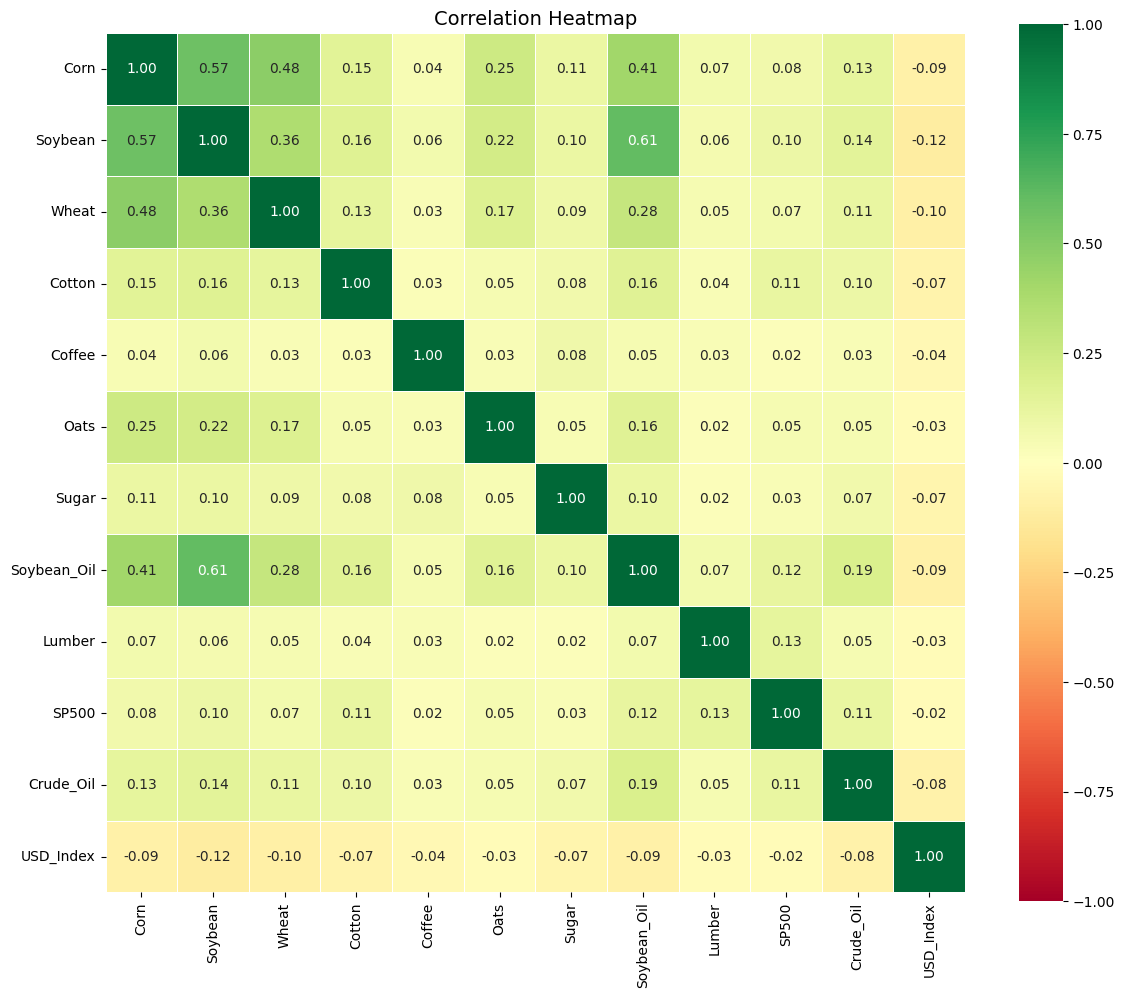

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

corr = master.drop(columns='Date').corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('data/processed/correlation_heatmap.png', dpi=150)
plt.show()

### 1.5 Save Master CSV

Export the clean, synchronized master dataset for use in the next phases.

In [6]:
os.makedirs('data/processed', exist_ok=True)
master.to_csv('data/processed/master_data.csv', index=False)
print(f'Saved master dataset: {master.shape[0]} rows x {master.shape[1]} columns')

Saved master dataset: 9601 rows x 13 columns
